1507
15752
4795.924268422927
1848.2526085366376
4102.0
3551


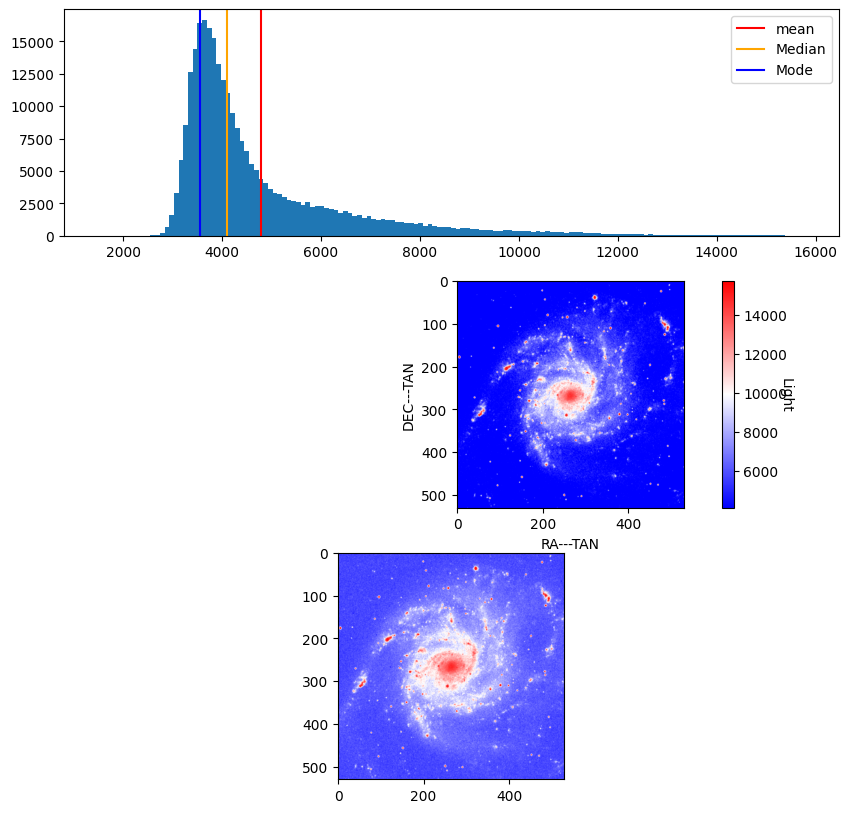

In [35]:
#6.1

from astropy.io import fits
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2)

hdulst = fits.open('m101.fits')
dat = hdulst[0].data
hdr = hdulst[0].header
dat = dat.flatten()


#print(hdr)


npdat = np.reshape(np.asarray(dat), (530, 530))

npmin = np.min(dat)
npmax = np.max(dat)
npmean = np.mean(dat)
npstd = np.std(dat)
npmedian = np.median(dat)
npmode, _ = st.mode(dat)
print(npmin)
print(npmax)
print(npmean)
print(npstd)
print(npmedian)
print(npmode)

ax[0].hist(dat, bins=150)
ax[0].axvline(npmean, color='r', label='mean')
ax[0].axvline(npmedian, color='orange', label='Median')
ax[0].axvline(npmode, color='b', label='Mode')
pos = ax[1].imshow(npdat, cmap = 'bwr', vmin = npmedian)
ax[1].set_xlabel('RA---TAN')
ax[1].set_ylabel('DEC---TAN')
ax[0].legend()
cbar = fig.colorbar(pos)
cbar.set_label('Light', rotation=270)
fig.set_figheight(10)
fig.set_figwidth(10)

hdr["BUNIT"] = 'Counts'


hdulistout = fits.PrimaryHDU(npdat)
hdulistout.header = hdr
hdulistout.writeto('pic.fits', overwrite=True, output_verify='ignore')

2 hdus
hdu 0
int16
bitpix = 16, yup
matches naxis 1 and 2, all are 530
yup, int16
RA---TAN, DEC--TAN

In [44]:
#6.3

from astropy.io import fits
import numpy as np

hdulst = fits.open('m101.fits')
dat = hdulst[0].data
hdr = hdulst[0].header
mydat = dat[0:19,0:19].flatten()

sum = 0
for i in mydat:
    sum += (i)**2
sum = sum/np.size(mydat)
ans = np.sqrt(sum)
print(ans)
print(np.mean(mydat))
print(np.std(mydat))

3442.5164288469105
3432.6371191135736
260.61805648218944


RMS is better, because negatives gone (not this case but still), and big difference makes bigger difference

(3, 893, 891)
(893, 891)
5.773191380233297
33.32975290315724


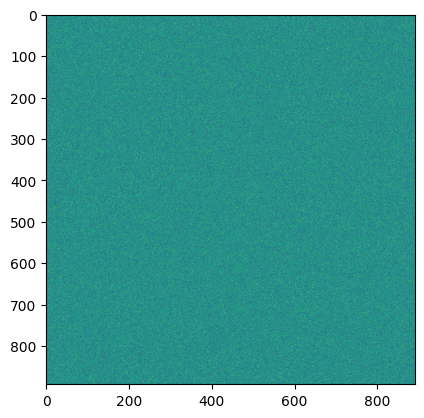

In [97]:
#6.5

from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

hdul0 = fits.open('noisemap0.fits')[0].data
hdul1 = fits.open('noisemap1.fits')[0].data
hdul2 = fits.open('noisemap2.fits')[0].data

std1 = np.std(hdul0.flatten())
std2 = np.std(hdul1.flatten())
std3 = np.std(hdul2.flatten())

cube = np.stack((hdul0, hdul1, hdul2))
print(np.shape(cube))
minn = np.mean(cube, axis=0)
print(np.shape(minn))
supstd = np.std(minn)
print(supstd)

fminn = minn.flatten()
summ = np.sum(fminn**2)
summ = summ/np.size(fminn)

print(summ)

ax.imshow(minn)